In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.datasets import load_gbsg2
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
 
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [7]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [8]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [9]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [10]:
# Check if some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [11]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [12]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

In [13]:
clinical_train.head(10)

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
5,57.772603,1,0,0,0,1,1,0.0,0,59.658904,1.0,5.298506,2.846,10.424669,10.126027,1
6,55.791781,0,0,0,0,1,1,0.0,0,56.687671,1.0,8.340148,4.786,31.461777,87.978082,1
7,72.389041,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.301212,7.852,55.919707,53.983562,1
8,53.378082,1,0,1,0,0,1,1.0,0,0.000000,0.0,19.134939,5.898,92.534072,98.005479,0
9,59.076712,0,0,0,1,0,0,0.0,1,41.076712,1.0,17.184191,25.172,317.330329,3.419178,1


# Feature Selection

In [14]:
# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_dfs = y['event_DFS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_dfs):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        scaler = RobustScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='DFS', event_col='event_DFS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 111 total observations, 56 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 57 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 57 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
8      hpv_related                  57.400513
9      hypopharynx                  24.309008
13    uicc8_III-IV                  19.644982
11      oropharynx                  19.362653
10          larynx                  18.907006
0              MTV                  17.257115
12      pack_years                  16.128187
2              TLG                  14.153164
5         charlson                  12.360656
4       cavum_oris                  11.769264
3              age                   8.870729
1          SUVpeak                   8.764477
7   histgrade_high                   7.837984
6           female                   7.399066


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

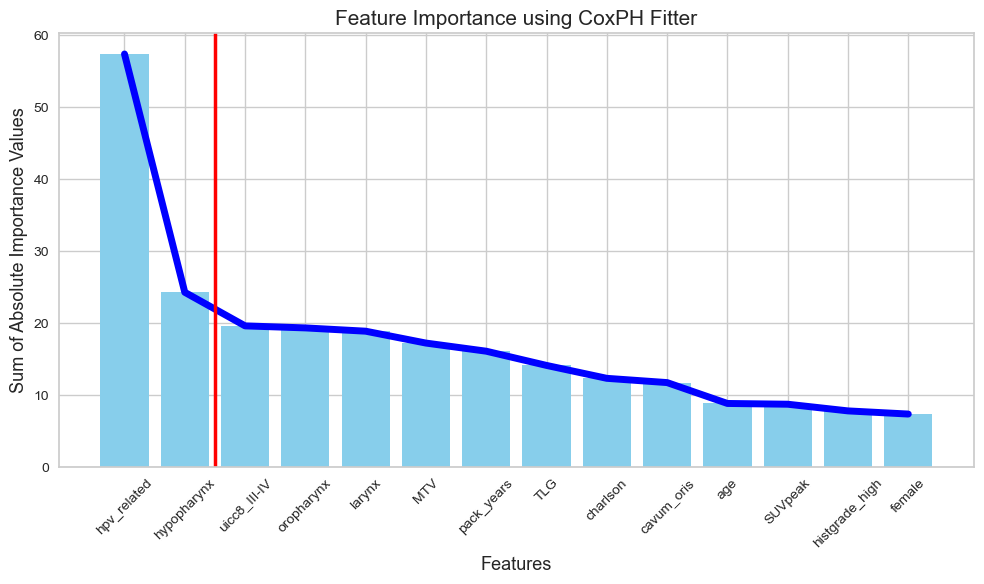

In [16]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=1.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [19]:
selected_features = final_sum_sorted[0:2]['Feature']
selected_features

8    hpv_related
9    hypopharynx
Name: Feature, dtype: object

In [20]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

# Standardization

In [21]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]

""" All columns selected are categoric

X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler()
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)
"""
# Change the order of the X_new_std 
X_new_std = X_new_categoric

' All columns selected are categoric\n\nX_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nscaler = RobustScaler()\nX_new_numeric_columns = X_new_numeric.columns\nX_new_numeric_index = X_new_numeric.index \nX_new_numeric_std = scaler.fit_transform(X_new_numeric)\nX_new_numeric_std = pd.DataFrame(X_new_numeric_std,\n                                 columns=X_new_numeric_columns, \n                                 index=X_new_numeric_index)\nX_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)\n'

In [22]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]

""" All columns selected are categoric
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler()
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)
"""
# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_categoric

' All columns selected are categoric\nMAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nscaler = RobustScaler()\nMAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns\nMAASTRO_new_numeric_index = MAASTRO_new_numeric.index \nMAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)\nMAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,\n                                 columns=MAASTRO_new_numeric_columns, \n                                 index=MAASTRO_new_numeric_index)\nMAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)\n'

In [23]:
X_new

,hpv_related,hypopharynx
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
...,...,...
134,1.0,0
135,1.0,0
136,1.0,0
137,1.0,0


In [24]:
X_new_std

,hpv_related,hypopharynx
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
...,...,...
134,1.0,0
135,1.0,0
136,1.0,0
137,1.0,0


In [25]:
MAASTRO_new

,hpv_related,hypopharynx
0,1,0
1,0,0
2,0,0
3,0,0
4,1,0
...,...,...
94,0,0
95,0,0
96,1,0
97,1,0


In [26]:
MAASTRO_new_std

,hpv_related,hypopharynx
0,1,0
1,0,0
2,0,0
3,0,0
4,1,0
...,...,...
94,0,0
95,0,0
96,1,0
97,1,0


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [27]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:09:14,879] A new study created in memory with name: no-name-39914ce8-7fa4-4474-bdd1-276fddace1e9


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:09:15,154] A new study created in memory with name: no-name-05f08160-03f7-4128-83a1-e31de1d55a11


Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:15,147] Trial 0 finished with value: 0.641387317547908 and parameters: {}. Best is trial 0 with value: 0.641387317547908.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.641387317547908], datetime_start=datetime.datetime(2024, 4, 13, 17, 9, 15, 3551), datetime_complete=datetime.datetime(2024, 4, 13, 17, 9, 15, 147302), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.641387317547908


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22280734698069957
Fold 2 IBS: 0.24599603610326043
Fold 3 IBS: 0.20337366096658827
Fold 4 IBS: 0.22100933621795185
Fold 5 IBS: 0.20601249512349532
[I 2024-04-13 17:09:15,343] Trial 0 finished with value: 0.21983977507839908 and parameters: {}. Best is trial 0 with value: 0.21983977507839908.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21983977507839908], datetime_start=datetime.datetime(2024, 4, 13, 17, 9, 15, 188948), datetime_complete=datetime.datetime(2024, 4, 13, 17, 9, 15, 342881), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21983977507839908


In [28]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [29]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.641
train_ibs:  0.22


#### Test

In [30]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [31]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.548
IBS score: 0.232


In [32]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [33]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [34]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:09:15,710] A new study created in memory with name: no-name-059633d3-0e13-49c8-8ab0-d64e07075a5b


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:09:15,834] A new study created in memory with name: no-name-dbcd1fae-5d95-48f0-a7a8-e788f9c5288d


Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:09:15,818] Trial 0 finished with value: 0.6366905799047093 and parameters: {}. Best is trial 0 with value: 0.6366905799047093.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6366905799047093], datetime_start=datetime.datetime(2024, 4, 13, 17, 9, 15, 760541), datetime_complete=datetime.datetime(2024, 4, 13, 17, 9, 15, 818456), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6366905799047093


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709770445535
Fold 2 IBS: 0.2320398829421048
Fold 3 IBS: 0.22898186520676508
Fold 4 IBS: 0.24197476845241006
Fold 5 IBS: 0.22939559078639188
[I 2024-04-13 17:09:15,976] Trial 0 finished with value: 0.23592784101842543 and parameters: {}. Best is trial 0 with value: 0.23592784101842543.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784101842543], datetime_start=datetime.datetime(2024, 4, 13, 17, 9, 15, 868373), datetime_complete=datetime.datetime(2024, 4, 13, 17, 9, 15, 976476), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784101842543


In [35]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [36]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.637
train_ibs:  0.236


#### Test

In [37]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [38]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.598


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [39]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [40]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:09:16,461] A new study created in memory with name: no-name-438a5d09-2baa-4996-bda9-371185b3821f


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:09:16,658] A new study created in memory with name: no-name-466581b2-16f5-4787-ab43-3420d7813ad2


Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:16,652] Trial 0 finished with value: 0.6358096283048801 and parameters: {}. Best is trial 0 with value: 0.6358096283048801.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6358096283048801], datetime_start=datetime.datetime(2024, 4, 13, 17, 9, 16, 497671), datetime_complete=datetime.datetime(2024, 4, 13, 17, 9, 16, 652078), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6358096283048801


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22326816649378833
Fold 2 IBS: 0.24437073686782668
Fold 3 IBS: 0.20345913714943464
Fold 4 IBS: 0.2206414558906958
Fold 5 IBS: 0.20670661089592982
[I 2024-04-13 17:09:16,924] Trial 0 finished with value: 0.21968922145953504 and parameters: {}. Best is trial 0 with value: 0.21968922145953504.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21968922145953504], datetime_start=datetime.datetime(2024, 4, 13, 17, 9, 16, 710391), datetime_complete=datetime.datetime(2024, 4, 13, 17, 9, 16, 924387), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21968922145953504


In [41]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [42]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.636
train_ibs:  0.22


#### Test

In [43]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [44]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.548


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.231


In [45]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [46]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:09:17,225] A new study created in memory with name: no-name-0cb9ba5c-a501-4c45-b13c-b8c19a5253c4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:17,456] Trial 0 finished with value: 0.6358096283048801 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6358096283048801.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:17,674] Trial 1 finished with value: 0.6380909971261729 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6380909971261729.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:09:17,777] Trial 2 finished with value: 0.6366905799047093 and parameters: {'l1_ratio': 0.22692876841884668}. Be

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:21,940] Trial 25 finished with value: 0.6358096283048801 and parameters: {'l1_ratio': 0.42489614367955286}. Best is trial 13 with value: 0.6435173537153202.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:22,335] Trial 26 finished with value: 0.6358096283048801 and parameters: {'l1_ratio': 0.3527001258697712}. Best is trial 13 with value: 0.6435173537153202.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:09:22,445] Trial 27 finished with value: 0.6366905799047093 and parameters: {'l1_ratio': 0.09486155085202524

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:09:26,356] Trial 49 finished with value: 0.6366905799047093 and parameters: {'l1_ratio': 0.1314053399823791}. Best is trial 13 with value: 0.6435173537153202.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:26,580] Trial 50 finished with value: 0.6358096283048801 and parameters: {'l1_ratio': 0.6064718647459368}. Best is trial 13 with value: 0.6435173537153202.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:09:26,772] Trial 51 finished with value: 0.6435173537153202 and parameters: {'l1_ratio': 0.25386382942223884

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.22326886529691073
Fold 2 IBS: 0.24433983917897925
Fold 3 IBS: 0.20345890360924163
Fold 4 IBS: 0.22067214920739425
Fold 5 IBS: 0.20661561980711463
[I 2024-04-13 17:09:34,532] Trial 0 finished with value: 0.2196710754199281 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.2196710754199281.
Fold 1 IBS: 0.2232685645173039
Fold 2 IBS: 0.2444024085316468
Fold 3 IBS: 0.20344490998462228
Fold 4 IBS: 0.23535239124869783
Fold 5 IBS: 0.20652291100814613
[I 2024-04-13 17:09:34,830] Trial 1 finished with value: 0.22259823705808338 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.2196710754199281.
Fold 1 IBS: 0.22326899409398612
Fold 2 IBS: 0.22910469892979343
Fold 3 IBS: 0.2234674652030817
Fold 4 IBS: 0.23645133312318467
Fold 5 IBS: 0.22509043345132884
[I 2024-04-13 17:09:34,982] Trial 2 finished with value: 0.22747658496027495 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.219671075419928

Fold 2 IBS: 0.244350281703639
Fold 3 IBS: 0.20344799303303257
Fold 4 IBS: 0.22067897354387142
Fold 5 IBS: 0.20657129289445134
[I 2024-04-13 17:09:39,965] Trial 25 finished with value: 0.21966340648996724 and parameters: {'l1_ratio': 0.45846211730023634}. Best is trial 21 with value: 0.2196608623940292.
Fold 1 IBS: 0.22326879520367562
Fold 2 IBS: 0.24442884253609853
Fold 3 IBS: 0.20345298698402844
Fold 4 IBS: 0.2206905186589248
Fold 5 IBS: 0.206607423477721
[I 2024-04-13 17:09:40,195] Trial 26 finished with value: 0.21968971337208965 and parameters: {'l1_ratio': 0.4854060940881682}. Best is trial 21 with value: 0.2196608623940292.
Fold 1 IBS: 0.2232684223114713
Fold 2 IBS: 0.2443823305474963
Fold 3 IBS: 0.20346055930779602
Fold 4 IBS: 0.2206673517337328
Fold 5 IBS: 0.2066366062854812
[I 2024-04-13 17:09:40,458] Trial 27 finished with value: 0.21968305403719554 and parameters: {'l1_ratio': 0.8031906542448771}. Best is trial 21 with value: 0.2196608623940292.
Fold 1 IBS: 0.223268702305775

Fold 1 IBS: 0.22326900617345988
Fold 2 IBS: 0.229517506554144
Fold 3 IBS: 0.2242799060914409
Fold 4 IBS: 0.23723309735899792
Fold 5 IBS: 0.22571836729732606
[I 2024-04-13 17:09:46,374] Trial 51 finished with value: 0.22800357669507373 and parameters: {'l1_ratio': 0.18829753191911658}. Best is trial 49 with value: 0.21958820811253482.
Fold 1 IBS: 0.22326877872270362
Fold 2 IBS: 0.2288280515731155
Fold 3 IBS: 0.2034446975386142
Fold 4 IBS: 0.23592461530668166
Fold 5 IBS: 0.20651540123364945
[I 2024-04-13 17:09:46,621] Trial 52 finished with value: 0.2195963088749529 and parameters: {'l1_ratio': 0.25456489706884644}. Best is trial 49 with value: 0.21958820811253482.
Fold 1 IBS: 0.22326849469205706
Fold 2 IBS: 0.24442427251809873
Fold 3 IBS: 0.20345053186483328
Fold 4 IBS: 0.23576572222712777
Fold 5 IBS: 0.20650434115670852
[I 2024-04-13 17:09:47,001] Trial 53 finished with value: 0.22268267249176507 and parameters: {'l1_ratio': 0.26317641857572843}. Best is trial 49 with value: 0.21958820

Fold 5 IBS: 0.20653160761434738
[I 2024-04-13 17:09:51,759] Trial 76 finished with value: 0.21966693595147846 and parameters: {'l1_ratio': 0.24289755456331186}. Best is trial 49 with value: 0.21958820811253482.
Fold 1 IBS: 0.22326845147179278
Fold 2 IBS: 0.24443203571434888
Fold 3 IBS: 0.2034501408029869
Fold 4 IBS: 0.23573890896734745
Fold 5 IBS: 0.20654976280788764
[I 2024-04-13 17:09:51,968] Trial 77 finished with value: 0.2226878599528727 and parameters: {'l1_ratio': 0.26464265959558536}. Best is trial 49 with value: 0.21958820811253482.
Fold 1 IBS: 0.22326853912570213
Fold 2 IBS: 0.24445191562611518
Fold 3 IBS: 0.2034615269643166
Fold 4 IBS: 0.22066509791208153
Fold 5 IBS: 0.20665552276991392
[I 2024-04-13 17:09:52,181] Trial 78 finished with value: 0.2197005204796259 and parameters: {'l1_ratio': 0.9506480490309224}. Best is trial 49 with value: 0.21958820811253482.
Fold 1 IBS: 0.242933800306325
Fold 2 IBS: 0.2296299965478157
Fold 3 IBS: 0.22449873012702162
Fold 4 IBS: 0.237445446

In [47]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [48]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.644
train_ibs:  0.22


#### Test

In [49]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [50]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.25175477458330975)

test_cindex : 0.548


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.25591919063585944)

test_ibs:  0.231


In [51]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [52]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:09:56,613] A new study created in memory with name: no-name-faababe6-0d4f-4296-9d6b-35f3cba12bc6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:09:59,162] Trial 0 finished with value: 0.6366905799047093 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6366905799047093.
Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:10:01,355] Trial 1 finished with value: 0.641387317547908 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'ma

Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:10:27,778] Trial 15 finished with value: 0.6366905799047093 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 15, 'max_depth': 16, 'n_estimators': 383, 'oob_score': True, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.07489943755174594, 'warm_start': False}. Best is trial 2 with value: 0.6468136741370553.
Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6553191489361702
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:10:32,425] Trial 16 finished with value: 0.6374519720093957 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 8, 'n_estimators': 493, 'oob_score': True, 'max_samples': 0.8594364161746585, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1838865535897828, 'warm_start': False}. Best is trial 2 with value: 0.64681367413705

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:10:59,229] Trial 30 finished with value: 0.6366905799047093 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 332, 'oob_score': False, 'max_samples': 0.8346135739676636, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.2486312042554125, 'warm_start': False}. Best is trial 2 with value: 0.6468136741370553.
Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:11:01,863] Trial 31 finished with value: 0.6468136741370553 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 10, 'max_depth': 18, 'n_estimators': 335, 'oob_score': False, 'max_samples': 0.91653749382894

...

Fold 1 IBS: 0.22229379521403375
Fold 2 IBS: 0.23159212209126462
Fold 3 IBS: 0.20639532766658014
Fold 4 IBS: 0.21663541994445548
Fold 5 IBS: 0.2125329724511093
[I 2024-04-13 17:15:21,982] Trial 32 finished with value: 0.21788992747348862 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 7, 'min_samples_leaf': 9, 'max_depth': 6, 'n_estimators': 114, 'oob_score': False, 'max_samples': 0.6752379846937863, 'max_features': None, 'min_weight_fraction_leaf': 0.1533788469953533}. Best is trial 5 with value: 0.2169161347485778.
Fold 1 IBS: 0.2464963830119396
Fold 2 IBS: 0.2322133591599514
Fold 3 IBS: 0.22934012914094246
Fold 4 IBS: 0.2414280200775274
Fold 5 IBS: 0.23034309914979342
[I 2024-04-13 17:15:23,809] Trial 33 finished with value: 0.23596419810803085 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 189, 'oob_score': False, 'max_samples': 0.49731140683066316, 'max_features': None, 'min_weight_fraction_leaf': 0.3

Fold 1 IBS: 0.2465906169620169
Fold 2 IBS: 0.23210226191895486
Fold 3 IBS: 0.22941271457856557
Fold 4 IBS: 0.24163431609235608
Fold 5 IBS: 0.2301585658071135
[I 2024-04-13 17:16:11,147] Trial 48 finished with value: 0.2359796950718014 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 172, 'oob_score': False, 'max_samples': 0.8018242912232848, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 5 with value: 0.2169161347485778.
Fold 1 IBS: 0.2243284983218128
Fold 2 IBS: 0.22643722194218632
Fold 3 IBS: 0.20991420856557064
Fold 4 IBS: 0.21871202042844487
Fold 5 IBS: 0.21217073732743072
[I 2024-04-13 17:16:14,146] Trial 49 finished with value: 0.21831253731708905 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 16, 'min_samples_leaf': 20, 'max_depth': 9, 'n_estimators': 284, 'oob_score': False, 'max_samples': 0.6051977518162043, 'max_features': None, 'min_weight_fraction_leaf':

Fold 1 IBS: 0.22156741810046876
Fold 2 IBS: 0.2276892362634309
Fold 3 IBS: 0.2055587149387753
Fold 4 IBS: 0.22046668126441685
Fold 5 IBS: 0.21349006089241335
[I 2024-04-13 17:16:52,307] Trial 64 finished with value: 0.21775442229190106 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 24, 'oob_score': False, 'max_samples': 0.9275903685256646, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.10816494647733825}. Best is trial 5 with value: 0.2169161347485778.
Fold 1 IBS: 0.21767500475868015
Fold 2 IBS: 0.24926432863662626
Fold 3 IBS: 0.2069327271318582
Fold 4 IBS: 0.2232255208054162
Fold 5 IBS: 0.20846958373198596
[I 2024-04-13 17:16:52,815] Trial 65 finished with value: 0.22111343301291334 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 4, 'n_estimators': 32, 'oob_score': False, 'max_samples': 0.8676554179900138, 'max_features': 'auto', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.22739140822692974
Fold 2 IBS: 0.22462992743082832
Fold 3 IBS: 0.2121189703353496
Fold 4 IBS: 0.2228566042302832
Fold 5 IBS: 0.21531146544487131
[I 2024-04-13 17:17:05,900] Trial 80 finished with value: 0.22046167513365242 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 4, 'n_estimators': 44, 'oob_score': True, 'max_samples': 0.8399375845532439, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1682309844440123}. Best is trial 72 with value: 0.2166805772751898.
Fold 1 IBS: 0.22670747721196682
Fold 2 IBS: 0.22458731797677195
Fold 3 IBS: 0.21075603415895172
Fold 4 IBS: 0.22271153185753337
Fold 5 IBS: 0.2149396143793694
[I 2024-04-13 17:17:06,580] Trial 81 finished with value: 0.21994039511691868 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 1, 'n_estimators': 30, 'oob_score': True, 'max_samples': 0.9596237410114419, 'max_features': 'auto', 'min_weight_fraction_leaf':

Fold 3 IBS: 0.20954061250834458
Fold 4 IBS: 0.21665542422736933
Fold 5 IBS: 0.21316248517990719
[I 2024-04-13 17:17:15,142] Trial 96 finished with value: 0.21799275788879155 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 10, 'oob_score': True, 'max_samples': 0.789233666267724, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.20175596450563218}. Best is trial 72 with value: 0.2166805772751898.
Fold 1 IBS: 0.22741364244056766
Fold 2 IBS: 0.2246328487691924
Fold 3 IBS: 0.21130406669731394
Fold 4 IBS: 0.22280068721534071
Fold 5 IBS: 0.21518513762995478
[I 2024-04-13 17:17:16,345] Trial 97 finished with value: 0.2202672765504739 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 3, 'n_estimators': 73, 'oob_score': True, 'max_samples': 0.9679733344492085, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.3126608885366039}. Best is trial 72 with value: 0.2166805772

In [53]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [54]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.647
train_ibs:  0.217


#### Test

In [55]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [56]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=10, max_features='auto', max_leaf_nodes=10,
                     max_samples=0.9040502468054213, min_samples_leaf=9,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.15864274091016045,
                     n_estimators=213, random_state=123)

test_cindex:  0.548


RandomSurvivalForest(max_depth=2, max_features='auto', max_leaf_nodes=19,
                     max_samples=0.9048007522844342, min_samples_leaf=7,
                     min_samples_split=19,
                     min_weight_fraction_leaf=0.17494452301960986,
                     n_estimators=4, oob_score=True, random_state=123)

test_ibs:  0.218


In [57]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [58]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:17:19,397] A new study created in memory with name: no-name-938a3b62-ec72-4669-b7b7-f04f2ed061a2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:17:20,462] Trial 0 finished with value: 0.641387317547908 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.641387317547908.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:17:22,575] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. 

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:18:03,318] Trial 16 finished with value: 0.6366905799047093 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 5, 'min_samples_leaf': 14, 'max_depth': 20, 'n_estimators': 237, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.2250731317633532}. Best is trial 0 with value: 0.641387317547908.
Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.6553191489361702
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 17:18:07,272] Trial 17 finished with value: 0.6211411290832161 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 2, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 372, 'oob_score': False, 'warm_start': False, 'max_features': 0

Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:18:37,723] Trial 31 finished with value: 0.641387317547908 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 5, 'min_samples_leaf': 7, 'max_depth': 14, 'n_estimators': 419, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5931938751420387, 'min_weight_fraction_leaf': 0.002333549417188538}. Best is trial 0 with value: 0.641387317547908.
Fold 1 C-index: 0.6553784860557769
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:18:39,278] Trial 32 finished with value: 0.641387317547908 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 3, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 291, 'oob_score': False, 'warm_start': True, 'max_features': '

...

Fold 1 IBS: 0.22722665682792578
Fold 2 IBS: 0.22485277506582896
Fold 3 IBS: 0.21056878574201138
Fold 4 IBS: 0.22175781060085353
Fold 5 IBS: 0.21416478599123637
[I 2024-04-13 17:25:09,583] Trial 30 finished with value: 0.21971416284557121 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 14, 'min_samples_leaf': 10, 'max_depth': 7, 'n_estimators': 291, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.8205286319134851, 'min_weight_fraction_leaf': 0.2518668913605965}. Best is trial 15 with value: 0.21692060573075383.
Fold 1 IBS: 0.22324599707795345
Fold 2 IBS: 0.22572582034764155
Fold 3 IBS: 0.20726726363445627
Fold 4 IBS: 0.2193787239274525
Fold 5 IBS: 0.2110558853319268
[I 2024-04-13 17:25:15,864] Trial 31 finished with value: 0.2173347380638861 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 9, 'n_estimators': 357, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0

Fold 1 IBS: 0.22210950906666982
Fold 2 IBS: 0.2263783088222858
Fold 3 IBS: 0.20628550460539927
Fold 4 IBS: 0.2198154789570592
Fold 5 IBS: 0.21080174189861947
[I 2024-04-13 17:27:20,739] Trial 45 finished with value: 0.21707810867000674 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 7, 'max_depth': 15, 'n_estimators': 406, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8486268814674347, 'min_weight_fraction_leaf': 0.09985736862799018}. Best is trial 15 with value: 0.21692060573075383.
Fold 1 IBS: 0.22416098842646465
Fold 2 IBS: 0.22503966158300967
Fold 3 IBS: 0.20825985433154728
Fold 4 IBS: 0.21949898788265315
Fold 5 IBS: 0.21174264672983617
[I 2024-04-13 17:27:30,920] Trial 46 finished with value: 0.21774042779070218 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 3, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 399, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0

Fold 1 IBS: 0.21920976399133738
Fold 2 IBS: 0.2318811297260619
Fold 3 IBS: 0.2059006192720417
Fold 4 IBS: 0.22147003939410007
Fold 5 IBS: 0.2095853021018681
[I 2024-04-13 17:29:17,505] Trial 60 finished with value: 0.21760937089708182 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 102, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7568857123824373, 'min_weight_fraction_leaf': 0.07268002063404566}. Best is trial 51 with value: 0.21688075177212313.
Fold 1 IBS: 0.22083212492884333
Fold 2 IBS: 0.2268780611161298
Fold 3 IBS: 0.20619628057895423
Fold 4 IBS: 0.22053181282648318
Fold 5 IBS: 0.2098164071957934
[I 2024-04-13 17:29:27,877] Trial 61 finished with value: 0.2168509373292408 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 8, 'max_depth': 11, 'n_estimators': 458, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.903

Fold 1 IBS: 0.23316779181000774
Fold 2 IBS: 0.22581497612755244
Fold 3 IBS: 0.22033799779873728
Fold 4 IBS: 0.23110628841718173
Fold 5 IBS: 0.2167108141911244
[I 2024-04-13 17:32:04,900] Trial 75 finished with value: 0.22542757366892072 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 8, 'max_depth': 9, 'n_estimators': 447, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.9391330010814033, 'min_weight_fraction_leaf': 0.38792353869222}. Best is trial 66 with value: 0.2166351940763669.
Fold 1 IBS: 0.2251584148715236
Fold 2 IBS: 0.22475092178959719
Fold 3 IBS: 0.20912209035039503
Fold 4 IBS: 0.2194531640254425
Fold 5 IBS: 0.2131138902105753
[I 2024-04-13 17:32:15,217] Trial 76 finished with value: 0.21831969624950673 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 4, 'min_samples_leaf': 10, 'max_depth': 7, 'n_estimators': 487, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.95003

Fold 1 IBS: 0.2192013647448416
Fold 2 IBS: 0.22932079209708478
Fold 3 IBS: 0.20575910638472572
Fold 4 IBS: 0.22151677220731447
Fold 5 IBS: 0.20880517405573829
[I 2024-04-13 17:34:47,547] Trial 90 finished with value: 0.21692064189794097 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 6, 'n_estimators': 439, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8978222774773456, 'min_weight_fraction_leaf': 0.08125231523241719}. Best is trial 66 with value: 0.2166351940763669.
Fold 1 IBS: 0.21857192107711435
Fold 2 IBS: 0.2314316114696419
Fold 3 IBS: 0.20536421838191404
Fold 4 IBS: 0.22173906079122635
Fold 5 IBS: 0.2085049961948352
[I 2024-04-13 17:34:57,501] Trial 91 finished with value: 0.21712236158294634 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 347, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.98

In [59]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [60]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.647
train_ibs:  0.217


#### Test

In [61]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [62]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=6, max_features='auto', max_leaf_nodes=6,
                   max_samples=0.8432870147525621, min_samples_leaf=2,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.17397498693499586,
                   n_estimators=467, random_state=123)

C-index score: 0.598


ExtraSurvivalTrees(max_depth=6, max_leaf_nodes=3,
                   max_samples=0.9561479691385143, min_samples_leaf=8,
                   min_samples_split=13,
                   min_weight_fraction_leaf=0.04451642932840062,
                   n_estimators=481, oob_score=True, random_state=123)

IBS: 0.237


In [63]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [64]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:36:47,067] A new study created in memory with name: no-name-f12638c0-0ea8-4f2e-a698-ab177f1ae33f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:37:30,579] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:37:53,300] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:53:49,108] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6366905799047093.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:56:33,088] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-13 18:22:07,145] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6366905799047093.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:24:55,845] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:55:03,242] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 9 with value: 0.23563784286235126.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 20:55:15,623] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435, 'dropout_rate': 0.85957479691200

Fold 5 IBS: 0.2270781607099746
[I 2024-04-13 21:09:06,643] Trial 55 finished with value: 0.2334412460011958 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 51 with value: 0.2321603648035265.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:10:28,074] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.030884976740502446, 'dropout_rate': 0.19804020971050568, 'n_estimators': 358, 

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:21:55,122] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.3366291337803353, 'learning_rate': 0.03684138433344805, 'dropout_rate': 0.1328866027244634, 'n_estimators': 319, 'criterion': 'friedman_mse', 'ccp_alpha': 1.0074500878262913, 'min_weight_fraction_leaf': 0.40650496560519606, 'max_features': None, 'min_impurity_decrease': 0.00018562329660606072, 'validation_fraction': 0.1720340754780943, 'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 12, 'max_depth': 16}. Best is trial 51 with value: 0.2321603648035265.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:22:45,932] Trial 68 finished with value: 0.23592784351233073 and parameters: {'s

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:34:22,512] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.38353946327089455, 'learning_rate': 0.04627201780375246, 'dropout_rate': 0.10185034849810722, 'n_estimators': 296, 'criterion': 'friedman_mse', 'ccp_alpha': 1.4077536708792413, 'min_weight_fraction_leaf': 0.37826406364062987, 'max_features': None, 'min_impurity_decrease': 4.870590304744988e-05, 'validation_fraction': 0.3211844074125865, 'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 10}. Best is trial 51 with value: 0.2321603648035265.
Fold 1 IBS: 0.24468935070624692
Fold 2 IBS: 0.23061896942092716
Fold 3 IBS: 0.22631495381783534
Fold 4 IBS: 0.23973726810389326
Fold 5 IBS: 0.227387179035944
[I 2024-04-13 21:35:38,077] Trial 79 finished with value: 0.23374954421696933 and parameters: {'subsample': 0.4449351033565357, '

Fold 3 IBS: 0.22522613671824526
Fold 4 IBS: 0.23890556708488297
Fold 5 IBS: 0.22648833845417632
[I 2024-04-13 21:46:58,218] Trial 89 finished with value: 0.23278608335364312 and parameters: {'subsample': 0.2799652441361268, 'learning_rate': 0.041598274959482893, 'dropout_rate': 0.21483185460780047, 'n_estimators': 350, 'criterion': 'friedman_mse', 'ccp_alpha': 0.019001072018239806, 'min_weight_fraction_leaf': 0.27872060184788355, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.5765746087299453, 'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 10, 'max_depth': 15}. Best is trial 51 with value: 0.2321603648035265.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:47:52,481] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.3053150575440778, 'learning_rate': 0.0413888302500

In [65]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [66]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.637
train_ibs:  0.232


#### Test

In [67]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [68]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.598


GradientBoostingSurvivalAnalysis(ccp_alpha=0.012687949334646564,
                                 dropout_rate=0.2080402615060769,
                                 learning_rate=0.04239876363366693,
                                 max_depth=12, max_leaf_nodes=4,
                                 min_impurity_decrease=0.00011584908890219409,
                                 min_samples_leaf=11,
                                 min_weight_fraction_leaf=0.34409642600595886,
                                 n_estimators=324, random_state=123,
                                 subsample=0.7104684936493832,
                                 validation_fraction=0.7396320573342624)

IBS: 0.226


In [69]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [70]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 22:13:01,929] A new study created in memory with name: no-name-937b12b3-7ba4-4237-8e1a-7914e34da28d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 22:13:02,791] Trial 0 finished with value: 0.6311128906616814 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6311128906616814.
Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 22:13:11,574] Trial 1 finished with value: 0.6333942594829742 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.6333942594829742.
Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6553191489361702
Fold 4 C-i

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 22:19:38,326] Trial 19 finished with value: 0.6366905799047093 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.7739543052925462, 'n_estimators': 426, 'learning_rate': 0.036212385990032875}. Best is trial 10 with value: 0.6366905799047093.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 22:19:40,314] Trial 20 finished with value: 0.6366905799047093 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.9097237456671665, 'n_estimators': 247, 'learning_rate': 0.017331004877487094}. Best is trial 10 with value: 0.6366905799047093.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
F

Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6553191489361702
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 22:21:16,671] Trial 38 finished with value: 0.6321451749153912 and parameters: {'subsample': 0.545660725139615, 'dropout_rate': 0.2946129812255986, 'n_estimators': 101, 'learning_rate': 0.013291484397437154}. Best is trial 28 with value: 0.6389719487260022.
Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 22:21:17,909] Trial 39 finished with value: 0.6311128906616814 and parameters: {'subsample': 0.7080667543236715, 'dropout_rate': 0.43405584635139455, 'n_estimators': 145, 'learning_rate': 0.03553221238759338}. Best is trial 28 with value: 0.6389719487260022.
Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6958174904942965
Fo

...

Fold 2 IBS: 0.23128344333133316
Fold 3 IBS: 0.20427188296829527
Fold 4 IBS: 0.21573220405535748
Fold 5 IBS: 0.21375363906639172
[I 2024-04-13 23:31:27,986] Trial 19 finished with value: 0.2178547685979025 and parameters: {'subsample': 0.6203097276533311, 'dropout_rate': 0.5750257507026826, 'n_estimators': 400, 'learning_rate': 0.014156757495385875}. Best is trial 6 with value: 0.21695653072853513.
Fold 1 IBS: 0.22501637569173205
Fold 2 IBS: 0.2276938545341352
Fold 3 IBS: 0.20459988217804337
Fold 4 IBS: 0.21664943096342437
Fold 5 IBS: 0.2129761169113823
[I 2024-04-13 23:31:34,763] Trial 20 finished with value: 0.2173871320557435 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.7859448591953863, 'n_estimators': 421, 'learning_rate': 0.011590415204380434}. Best is trial 6 with value: 0.21695653072853513.
Fold 1 IBS: 0.22483959027242598
Fold 2 IBS: 0.22535259573961794
Fold 3 IBS: 0.20599239439063427
Fold 4 IBS: 0.2186407592829741
Fold 5 IBS: 0.2124130235327216
[I 2024-0

Fold 2 IBS: 0.22501005211941655
Fold 3 IBS: 0.20641738244276467
Fold 4 IBS: 0.22000935412034864
Fold 5 IBS: 0.21215010168575113
[I 2024-04-13 23:32:28,869] Trial 38 finished with value: 0.217642566902088 and parameters: {'subsample': 0.5189193786041562, 'dropout_rate': 0.8390853273528575, 'n_estimators': 241, 'learning_rate': 0.015153469338083333}. Best is trial 28 with value: 0.21689725020998343.
Fold 1 IBS: 0.28360351892511165
Fold 2 IBS: 0.3087541817303555
Fold 3 IBS: 0.2490766629276894
Fold 4 IBS: 0.2604717441277904
Fold 5 IBS: 0.2762466469006547
[I 2024-04-13 23:32:34,855] Trial 39 finished with value: 0.27563055092232036 and parameters: {'subsample': 0.589341916686042, 'dropout_rate': 0.9208581105795851, 'n_estimators': 483, 'learning_rate': 0.06892741183938003}. Best is trial 28 with value: 0.21689725020998343.
Fold 1 IBS: 0.23943633002496906
Fold 2 IBS: 0.25418273353927534
Fold 3 IBS: 0.2136387098400327
Fold 4 IBS: 0.22120391612890683
Fold 5 IBS: 0.23251928898652022
[I 2024-04-

Fold 3 IBS: 0.20858551605081688
Fold 4 IBS: 0.2226783747356734
Fold 5 IBS: 0.21359471499953928
[I 2024-04-13 23:33:00,827] Trial 57 finished with value: 0.21914432245391993 and parameters: {'subsample': 0.7112093266749325, 'dropout_rate': 0.865012789866026, 'n_estimators': 141, 'learning_rate': 0.020535329468792267}. Best is trial 28 with value: 0.21689725020998343.
Fold 1 IBS: 0.22916862489729195
Fold 2 IBS: 0.22446273341132522
Fold 3 IBS: 0.21130227927277903
Fold 4 IBS: 0.22578861566134317
Fold 5 IBS: 0.21526358909889026
[I 2024-04-13 23:33:03,624] Trial 58 finished with value: 0.22119716846832596 and parameters: {'subsample': 0.6025167050454705, 'dropout_rate': 0.48058007261552127, 'n_estimators': 253, 'learning_rate': 0.009230871366451732}. Best is trial 28 with value: 0.21689725020998343.
Fold 1 IBS: 0.293637633357752
Fold 2 IBS: 0.3049281547784116
Fold 3 IBS: 0.24439802491881876
Fold 4 IBS: 0.25091165563071094
Fold 5 IBS: 0.2762108001816329
[I 2024-04-13 23:33:07,087] Trial 59 fi

Fold 3 IBS: 0.20478189688144174
Fold 4 IBS: 0.2156708987856193
Fold 5 IBS: 0.21629681665781605
[I 2024-04-13 23:34:50,682] Trial 76 finished with value: 0.2196471541977414 and parameters: {'subsample': 0.8197679129710136, 'dropout_rate': 0.4248907925428622, 'n_estimators': 403, 'learning_rate': 0.01587783783982852}. Best is trial 65 with value: 0.216851880263979.
Fold 1 IBS: 0.23887868778431076
Fold 2 IBS: 0.2277309865556894
Fold 3 IBS: 0.2209599087103631
Fold 4 IBS: 0.2346965191321087
Fold 5 IBS: 0.2226298664426489
[I 2024-04-13 23:34:53,205] Trial 77 finished with value: 0.2289791937250242 and parameters: {'subsample': 0.9431073319562439, 'dropout_rate': 0.2779898254578814, 'n_estimators': 162, 'learning_rate': 0.005607401755875655}. Best is trial 65 with value: 0.216851880263979.
Fold 1 IBS: 0.23039631647206674
Fold 2 IBS: 0.22470964906525775
Fold 3 IBS: 0.21275010029401717
Fold 4 IBS: 0.22686502261868355
Fold 5 IBS: 0.2160016362582088
[I 2024-04-13 23:34:56,310] Trial 78 finished w

Fold 4 IBS: 0.23678303865556707
Fold 5 IBS: 0.22450169217470564
[I 2024-04-13 23:36:21,851] Trial 95 finished with value: 0.23089268225146148 and parameters: {'subsample': 0.8107805134539307, 'dropout_rate': 0.5289559241877922, 'n_estimators': 185, 'learning_rate': 0.0034100560446759607}. Best is trial 65 with value: 0.216851880263979.
Fold 1 IBS: 0.22400329688212617
Fold 2 IBS: 0.2250869558546678
Fold 3 IBS: 0.206028722846008
Fold 4 IBS: 0.21938327609948652
Fold 5 IBS: 0.2120919707202443
[I 2024-04-13 23:36:23,808] Trial 96 finished with value: 0.21731884448050653 and parameters: {'subsample': 0.6824340851693498, 'dropout_rate': 0.9806455021652567, 'n_estimators': 197, 'learning_rate': 0.01906609599455617}. Best is trial 65 with value: 0.216851880263979.
Fold 1 IBS: 0.22380181814225164
Fold 2 IBS: 0.22550674774993915
Fold 3 IBS: 0.20540358242638554
Fold 4 IBS: 0.2188109943990184
Fold 5 IBS: 0.21203197509322386
[I 2024-04-13 23:36:25,286] Trial 97 finished with value: 0.217111023562163

In [71]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [72]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.639
train_ibs:  0.217


#### Test

In [73]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [74]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9288300747078483,
                                              learning_rate=0.09270903103329074,
                                              n_estimators=462,
                                              random_state=123,
                                              subsample=0.6692336821130495)

C-index score: 0.598


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9605840850152538,
                                              learning_rate=0.029305705951311493,
                                              n_estimators=159,
                                              random_state=123,
                                              subsample=0.669059506358328)

IBS: 0.221


In [75]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [76]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.647,1.5
ExtraSurvivalTrees,0.647,1.5
CoxElastic,0.644,3.0
CoxPH,0.641,4.0
ComponentwiseGradientBoosting,0.639,5.0
CoxRidge,0.637,6.5
GradientBoosting,0.637,6.5
CoxLasso,0.636,8.0


In [77]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.217,2.0
ExtraSurvivalTrees,0.217,2.0
ComponentwiseGradientBoosting,0.217,2.0
CoxPH,0.220,5.0
CoxLasso,0.220,5.0
CoxElastic,0.220,5.0
GradientBoosting,0.232,7.0
CoxRidge,0.236,8.0


In [78]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxRidge,0.598,2.5
ExtraSurvivalTrees,0.598,2.5
GradientBoosting,0.598,2.5
ComponentwiseGradientBoosting,0.598,2.5
CoxPH,0.548,6.5
CoxLasso,0.548,6.5
CoxElastic,0.548,6.5
Randomsurvivalforest,0.548,6.5


In [79]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.218,1.0
ComponentwiseGradientBoosting,0.221,2.0
GradientBoosting,0.226,3.0
CoxRidge,0.229,4.0
CoxLasso,0.231,5.5
CoxElastic,0.231,5.5
CoxPH,0.232,7.0
ExtraSurvivalTrees,0.237,8.0


In [80]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/robust/cfi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_robust_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [81]:
from datetime import date
today = date.today()
print("Date: ", today)


Date:  2024-04-13
